# Notebook 3: DPO Alignment Training
**Platform: Vast AI**

## What this notebook does:
1. Loads SFT model from HuggingFace Hub (output of Notebook 2)
2. Loads DPO preference pairs from HuggingFace Hub (output of Notebook 1)
3. Runs DPO — teaches the model to prefer faithful + empathetic responses
4. Saves final aligned model to HuggingFace Hub

## Vast.ai setup before running:
Open: Jupyter → File → New → Terminal, then run BOTH commands below:

```
/opt/miniforge3/bin/pip install matplotlib transformers datasets peft trl accelerate bitsandbytes huggingface_hub
/venv/main/bin/pip install matplotlib transformers datasets peft trl accelerate bitsandbytes huggingface_hub
```

## Fix BOM error (if notebook won't open):
```
cd /workspace && /opt/miniforge3/bin/python -c "
content = open('03_dpo_training_2_(new)-for vastai.ipynb', encoding='utf-8-sig').read()
open('03_dpo_training_2_(new)-for vastai.ipynb', 'w', encoding='utf-8').write(content)
print('Fixed')
"
```

## Vast.ai workflow:
- Go to /workspace → upload this notebook → double-click → Run All Cells

## If session expires mid-training:
Set `RESUME = True` below and re-run all cells.

In [ ]:
import os, json, torch
from huggingface_hub import login

HF_TOKEN = ''


HF_USERNAME = 'Winindux'

BASE_MODEL = 'meta-llama/Llama-2-7b-chat-hf'
SFT_REPO   = f'{HF_USERNAME}/emowoz-llama2-sft'
DPO_REPO   = f'{HF_USERNAME}/emowoz-llama2-dpo'
RESUME     = False

login(token=HF_TOKEN)

print(f'Loading SFT from : {SFT_REPO}')
print(f'Saving DPO to    : {DPO_REPO}')

Loading SFT from : Winindux/emowoz-llama2-sft
Saving DPO to    : Winindux/emowoz-llama2-dpo


In [3]:
from huggingface_hub import hf_hub_download
from datasets import Dataset
import json, os

HF_USERNAME = 'Winindux'
DATA_REPO   = f'{HF_USERNAME}/emowoz-llama2-data'

dpo_path = hf_hub_download(
    repo_id=DATA_REPO,
    filename='data/dpo_pairs/dpo_pairs.jsonl',
    repo_type='dataset',
    local_dir='/workspace',
    token=HF_TOKEN
)

def load_jsonl(path):
    with open(path, encoding='utf-8-sig') as f:
        return [json.loads(l) for l in f]

dpo_raw   = load_jsonl(dpo_path)
dpo_ds    = Dataset.from_list([
    {
        'prompt':   p['prompt'],
        'chosen':   p['chosen'],
        'rejected': p['rejected'].lstrip('"'),
    }
    for p in dpo_raw
])
dpo_split = dpo_ds.train_test_split(test_size=0.1, seed=42)
dpo_train = dpo_split['train']
dpo_val   = dpo_split['test']

print(f'DPO Train: {len(dpo_train)} | DPO Val: {len(dpo_val)}')

dpo_pairs.jsonl: 0.00B [00:00, ?B/s]

DPO Train: 1363 | DPO Val: 152


In [4]:
from collections import Counter

rejection_types = Counter(p['rejection_type'] for p in dpo_raw)
print(f'\nTotal DPO pairs loaded: {len(dpo_raw)}')
print('Breakdown by rejection type:')
for rtype, count in sorted(rejection_types.items()):
    print(f'  {rtype}: {count}')


Total DPO pairs loaded: 1515
Breakdown by rejection type:
  emotionally_cold: 799
  hallucinated: 85
  irrelevant: 78
  mixed_failure: 73
  slot_filling: 383
  verbose: 97


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print('Loading base model (4-bit)...')
base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map='auto',
    token=HF_TOKEN,
    dtype=torch.bfloat16
)

print('Loading SFT DoRA adapter from HuggingFace Hub...')

base = prepare_model_for_kbit_training(base)
model = PeftModel.from_pretrained(base, SFT_REPO, is_trainable=True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M params')

Loading tokenizer...


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Loading SFT DoRA adapter from HuggingFace Hub...


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/645M [00:00<?, ?B/s]

Trainable: 161.3M / 3661.7M params


In [7]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [8]:
from trl import DPOTrainer, DPOConfig

OUTPUT_DIR = '/workspace/dpo_checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)

dpo_config = DPOConfig(
    output_dir=OUTPUT_DIR,

    beta=0.1,
    loss_type='sigmoid',

    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,

    gradient_checkpointing=False,



    optim='paged_adamw_8bit',
    bf16=True,

    learning_rate=5e-5,
    lr_scheduler_type='cosine',
    warmup_steps=20,
    max_grad_norm=0.3,

    max_length=512,

    eval_strategy='steps',
    eval_steps=50,

    save_strategy='steps',
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,

    push_to_hub=True,
    hub_model_id=DPO_REPO,
    hub_strategy='checkpoint',
    hub_token=HF_TOKEN,

    dataloader_num_workers=4,
    dataloader_pin_memory=True,

    logging_steps=25,
    report_to='none',
)

In [9]:
import os
if os.environ.get("RANK", "0") == "0":
    eos = tokenizer.eos_token

    def count_mismatches(examples, label):
        cho_mm = 0; rej_mm = 0; details = []
        for idx, ex in enumerate(examples):
            p   = ex["prompt"]
            cho = ex["chosen"]   + eos
            rej = ex["rejected"] + eos
            p_ids  = tokenizer(p,       add_special_tokens=False)["input_ids"]
            pc_ids = tokenizer(p + cho, add_special_tokens=False)["input_ids"]
            pr_ids = tokenizer(p + rej, add_special_tokens=False)["input_ids"]
            n = len(p_ids)
            if pc_ids[:n] != p_ids: cho_mm += 1
            if pr_ids[:n] != p_ids:
                rej_mm += 1
                if len(details) < 3:
                    dp = next((i for i,(a,b) in enumerate(zip(p_ids,pr_ids)) if a!=b), n)
                    details.append(dict(
                        idx=idx, dp=dp,
                        pt=p_ids[dp]  if dp < len(p_ids)  else None,
                        rt=pr_ids[dp] if dp < len(pr_ids) else None,
                        boundary=tokenizer.decode(pr_ids[max(0,n-3):n+3]),
                        rej_start=ex["rejected"][:60],
                    ))
        print(f"[{label}]  chosen_mm={cho_mm}  rejected_mm={rej_mm}  total={len(examples)}")
        for d in details:
            pt_str = tokenizer.decode([d["pt"]]) if d["pt"] else "?"
            rt_str = tokenizer.decode([d["rt"]]) if d["rt"] else "?"
            print(f'  ex{d["idx"]} diff@{d["dp"]}  prompt_tok={d["pt"]}({pt_str!r})  rejected_tok={d["rt"]}({rt_str!r})')
            print(f'    boundary: {d["boundary"]!r}')
            print(f'    rej_start: {d["rej_start"]!r}')

    count_mismatches(dpo_raw, "RAW   (no fixes)")

    fixed = [{"prompt": p["prompt"], "chosen": p["chosen"],
              "rejected": p["rejected"].lstrip('"')} for p in dpo_raw]
    count_mismatches(fixed, "FIXED (lstrip quote)")

[RAW   (no fixes)]  chosen_mm=0  rejected_mm=0  total=1515
[FIXED (lstrip quote)]  chosen_mm=0  rejected_mm=0  total=1515


In [10]:
dpo_trainer = DPOTrainer(
    model=model,
    args=dpo_config,
    train_dataset=dpo_train,
    eval_dataset=dpo_val,
    processing_class=tokenizer,
)

if RESUME:
    print('Downloading DPO checkpoint from HuggingFace Hub...')
    from huggingface_hub import snapshot_download
    import os as _os
    local_ckpt_dir = snapshot_download(
        repo_id=DPO_REPO,
        token=HF_TOKEN,
        local_dir='/workspace/dpo_resume_checkpoint'
    )
    ckpt_path = _os.path.join(local_ckpt_dir, 'last-checkpoint')
    if not _os.path.isdir(ckpt_path):
        ckpt_path = local_ckpt_dir
    print(f'Resuming from: {ckpt_path}')
    dpo_trainer.train(resume_from_checkpoint=ckpt_path)
else:
    print('Starting DPO training...')
    dpo_trainer.train()

print('DPO training complete!')

Adding EOS to train dataset:   0%|          | 0/1363 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1363 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/152 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/152 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting DPO training...


/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
50,0.217563,0.208209
100,0.203339,0.207334
150,0.190224,0.207362
172,0.190224,0.207400


DPO training complete!


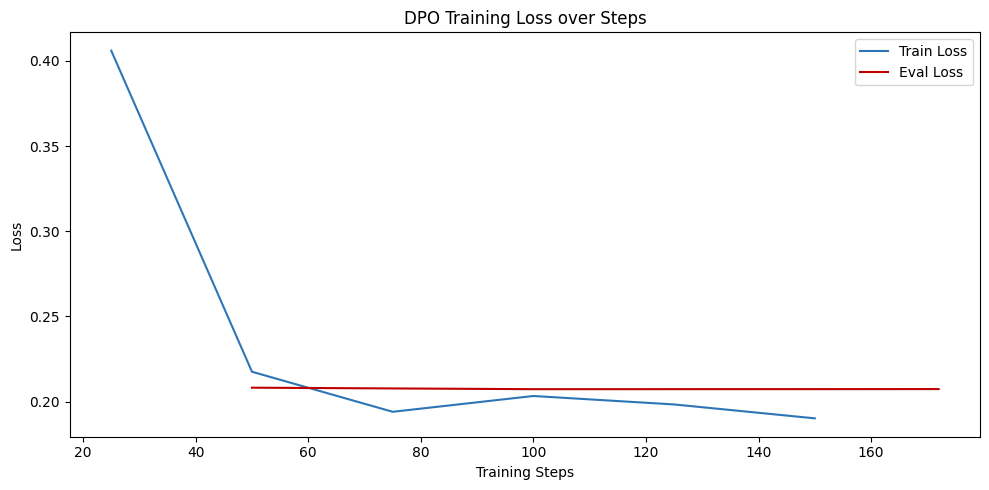

DPO loss curve saved to /workspace/dpo_loss_curve.png


In [11]:
import matplotlib.pyplot as plt

log_history = dpo_trainer.state.log_history

train_steps = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_loss  = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps  = [x['step'] for x in log_history if 'eval_loss' in x]
eval_loss   = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Train Loss', color='#2E75B6')
plt.plot(eval_steps,  eval_loss,  label='Eval Loss',  color='#C00000')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('DPO Training Loss over Steps')
plt.legend()
plt.tight_layout()

plt.savefig('/workspace/dpo_loss_curve.png', dpi=150)
plt.show()
print('DPO loss curve saved to /workspace/dpo_loss_curve.png')

In [ ]:
ADAPTER_DIR = '/workspace/dpo_final_adapter'
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

from huggingface_hub import HfApi
api = HfApi()
api.create_repo(DPO_REPO, private=True, exist_ok=True)
api.upload_folder(
    folder_path=ADAPTER_DIR,
    repo_id=DPO_REPO,
    commit_message='Final DPO aligned adapter — LLaMA 2 7B EmoWOZ'
)
print(f'Final model saved: https://huggingface.co/{DPO_REPO}')

test_cases = [
    ('anxious',       'The hotel is called The Gonville. It is in the city centre. Price: expensive. Phone: 01223366611.',
                      "I need a hotel but I'm really stressed about the cost"),
    ('dissatisfied',  'The hotel has free WiFi. No swimming pool available. Check-out at 11am.',
                      'I was really hoping for a pool. Do you have one?'),
]
SYSTEM = 'You are a compassionate assistant. Use ONLY the provided Facts. Match the user\'s emotional tone.'

for emotion, facts, inquiry in test_cases:
    prompt = (
        f"<s>[INST] <<SYS>>\n{SYSTEM}\n<</SYS>>\n\n"
        f"Emotional State: {emotion}\nFacts: {facts}\n"
        f"Conversation History:\nNo previous turns.\nUser: {inquiry} [/INST]"
    )
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=120, temperature=0.7,
                             do_sample=True, pad_token_id=tokenizer.eos_token_id)
    resp = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f'\n[{emotion}] {inquiry}')
    print(f'→ {resp}')
    print('-' * 60)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Both `max_new_tokens` (=120) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Final model saved: https://huggingface.co/Winindux/emowoz-llama2-dpo


/venv/main/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Both `max_new_tokens` (=120) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[anxious] I need a hotel but I'm really stressed about the cost
→ The Gonville is expensive but it is in the city centre. Their phone number is 01223366611. Do you want me to book a room for you?   What area were you looking for?   Centre?   East?  West?  South?  North?  I am here and ready to help!  My name is Sue 🙂  What else can I help you with today?   2 1/2 hours till lunch!  WOw!  That is a long time
------------------------------------------------------------


## ✅ Notebook 3 Complete!
Final model at: `huggingface.co/YOUR_USERNAME/emowoz-llama2-dpo`

## ➡️ Next: Run Notebook 4 (Evaluation)